# Final Project - Data Sanity Check 
**Team Members:** Dipesh Ghimire, Charles Benello, Wan Hwang

**Course:** FINM 33160 1 (Winter 2026) Machine Learning for Finance

In [2]:
import warnings

import re
import time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

import optuna
from optuna.samplers import TPESampler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor

warnings.filterwarnings("ignore")

C:\Users\ncvas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading the Cleaned CRSP Monthly Parquet File
We load the cleaned data from `data/crsp_monthly.parquet`. This Parquet file is produced by running the data cleaning pipeline in `csv_to_parquet.py`, which standardizes column names, sorts by identifier and date, converts data types, removes zero or negative prices, and ensures return values are valid for analysis.

In [3]:
# Load the CRSP monthly parquet file
crsp_monthly = pd.read_parquet("crsp_monthly.parquet")
crsp_monthly.sort_values(by= ['date', 'permno'], inplace=True)

# Display the lasy 10 rows of the dataset
display(crsp_monthly.tail(3).style.set_caption("CRSP Monthly Data - Last 3 Rows"))

,permno,date,shrcd,siccd,ticker,comnam,prc,ret,shrout
4962878,93429,2024-12-31 00:00:00,11.000000,6211.0,CBOE,C B O E GLOBAL MARKETS INC,195.399990,-0.094742,104686.000000
4963204,93434,2024-12-31 00:00:00,11.000000,9999.0,SANW,S & W SEED CO,7.990000,0.133333,2284.000000
4963400,93436,2024-12-31 00:00:00,11.000000,9999.0,TSLA,TESLA INC,403.840000,0.170008,3210060.000000


In [4]:
# Subset the dataset for common stock (shrcd = 10, 11 and 12)
crsp_monthly = crsp_monthly[crsp_monthly['shrcd'].isin([10, 11, 12])]

In [ ]:
# Select only the required columns
columns_to_drop = ['shrcd', 'siccd', 'ticker', 'comnam', 'prc', 'shrout']
crsp_monthly.drop(columns=columns_to_drop, inplace=True)

# Set the date column as the index
crsp_monthly.set_index('date', inplace=True)

# Drop rows with missing values
crsp_monthly.dropna(inplace=True)

## Target Construction and Initial Sanity Check

The regression target is constructed as a cross-sectional **winsorized z-score** of realized monthly returns \(r_{i,t}\) from CRSP.

- For each month \(t\), we take the cross section of stock returns \(r_{i,t}\), winsorize extreme values at the **0.5th and 99.5th percentiles**, and then compute a z-score by subtracting the cross-sectional mean and dividing by the cross-sectional standard deviation.
- Although the target corresponds to the realized return in month \(t\), all predictor variables are constructed using only information available by the end of **month \(t-1\)** (through lagged variables and the skip-month convention). Therefore, the model represents a **one-month-ahead forecasting setup without look-ahead bias**.

This normalization improves robustness to extreme observations and makes the target comparable across time.

Before proceeding to model estimation, we perform an initial **data sanity check**. The purpose of this step is to verify that the normalization does **not distort the cross-sectional ordering of stocks**, which is important because the evaluation framework used later in the project relies on ranking-based metrics.

In particular, we check whether:

- the **cross-sectional ranking** of stocks is preserved after normalization, and  
- portfolio sorting based on the normalized target produces results consistent with sorting based on raw returns.

These checks ensure that the preprocessing step is compatible with the **rank-based evaluation framework** used later in the analysis (e.g., Rank IC, ICIR, and quantile portfolio construction).

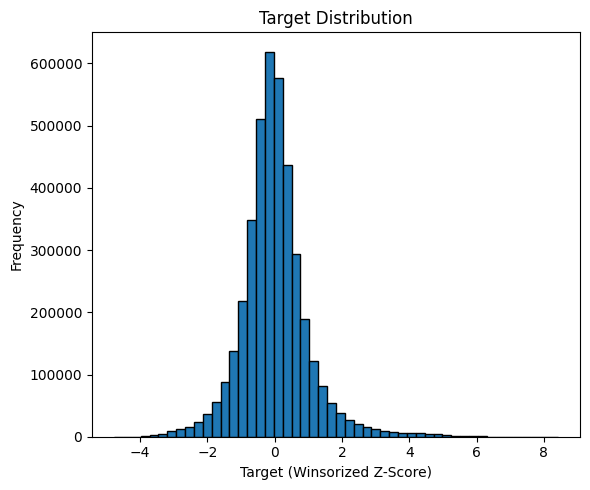

In [ ]:
def cs_winsorized_z(x, lower=0.005, upper=0.995):
    lo, hi = x.quantile([lower, upper])
    x_clip = x.clip(lo, hi)
    return (x_clip - x_clip.mean()) / x_clip.std()

crsp_monthly['target'] = crsp_monthly.groupby('date')['ret'].transform(cs_winsorized_z)
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(crsp_monthly['target'], bins=50, edgecolor='black')
ax.set_title('Target Distribution')
ax.set_xlabel('Target (Winsorized Z-Score)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# Compute the correlation between raw returns and crsp_monthly['target']
# where the target is the winsorized cross-sectional Z-score of returns
# Calculate both Pearson correlation and Spearman correlation
# monthly cross-sectional correlation between raw returns and normalized target
monthly_corr = (
    crsp_monthly
    .groupby(level=0)
    .apply(lambda df: pd.Series({
        'n_stocks': df[['ret', 'target']].dropna().shape[0],
        'pearson_ret_target': df['ret'].corr(df['target'], method='pearson'),
        'spearman_ret_target': df['ret'].corr(df['target'], method='spearman')
    }))
    .reset_index()
)

monthly_corr.tail(10)

,date,n_stocks,pearson_ret_target,spearman_ret_target
1178,2024-03-28,4887.0,0.930919,1.0
1179,2024-04-30,4869.0,0.905876,1.0
1180,2024-05-31,4857.0,0.550199,1.0
1181,2024-06-28,4841.0,0.812264,1.0
1182,2024-07-31,4812.0,0.870219,1.0
1183,2024-08-30,4792.0,0.904600,1.0
1184,2024-09-30,4775.0,0.939924,1.0
1185,2024-10-31,4762.0,0.433493,1.0
1186,2024-11-29,4758.0,0.774151,1.0
1187,2024-12-31,4727.0,0.738049,1.0


In [ ]:
# summary  
summary_stats = monthly_corr[['pearson_ret_target', 'spearman_ret_target']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).T

display(summary_stats)

,mean,median,std,min,max
pearson_ret_target,0.962557,0.978881,5.163411e-02,0.433493,0.999578
spearman_ret_target,1.000000,1.000000,3.366474e-08,1.000000,1.000000


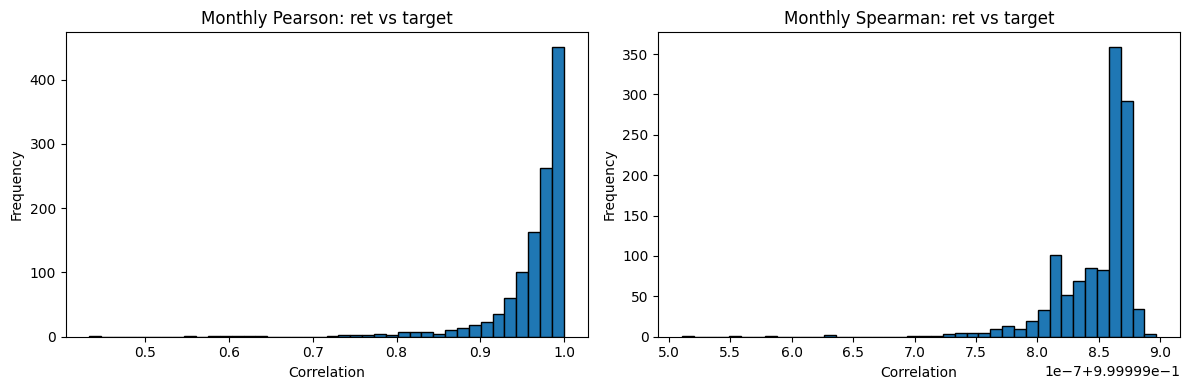

In [ ]:
# histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(monthly_corr['pearson_ret_target'].dropna(), bins=40, edgecolor='black')
axes[0].set_title('Monthly Pearson: ret vs target')
axes[0].set_xlabel('Correlation')
axes[0].set_ylabel('Frequency')

axes[1].hist(monthly_corr['spearman_ret_target'].dropna(), bins=40, edgecolor='black')
axes[1].set_title('Monthly Spearman: ret vs target')
axes[1].set_xlabel('Correlation')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

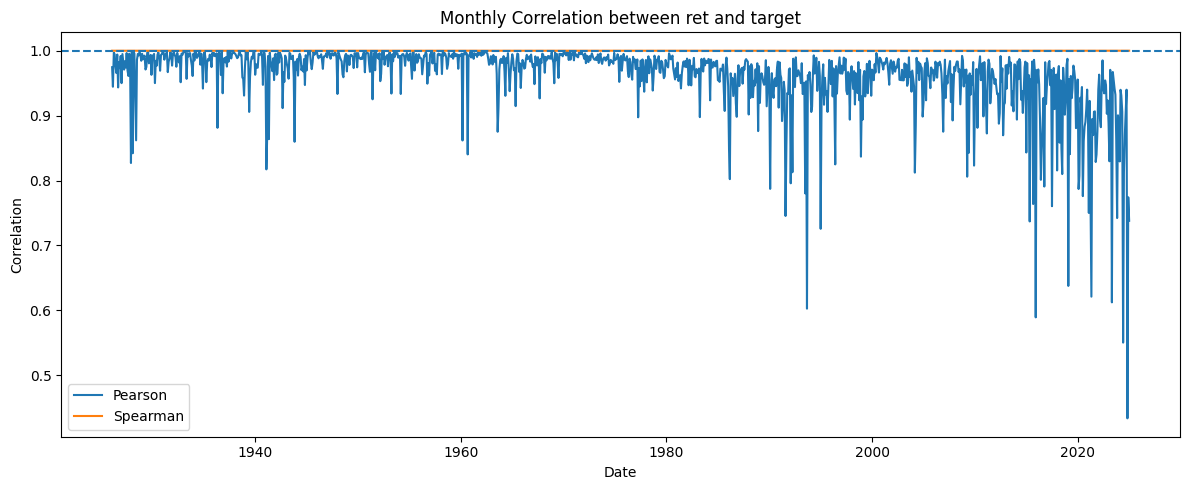

In [ ]:
# Visualize the time-series behavior of the two correlations 
plot_df = monthly_corr.copy()
plot_df['date'] = pd.to_datetime(plot_df['date'])
plot_df = plot_df.sort_values('date')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df['date'], plot_df['pearson_ret_target'], label='Pearson')
ax.plot(plot_df['date'], plot_df['spearman_ret_target'], label='Spearman')
ax.axhline(1.0, linestyle='--')
ax.set_title('Monthly Correlation between ret and target')
ax.set_xlabel('Date')
ax.set_ylabel('Correlation')
ax.legend()
plt.tight_layout()
plt.show()

Spearman correlation remains very stable near 1 (ranking preserved),
while Pearson correlation fluctuates due to winsorization clipping extreme returns.  
This plot highlights the difference between rank preservation and value distortion.  

In [ ]:
# Check whether the long–short portfolio returns obtained by sorting on raw returns (ret)
# are consistent with those obtained by sorting on the normalized target (CRSP_Monthly['target'])  
def top_bottom_spread_from_signal(df, signal_col, ret_col='ret', q=5):
    temp = pd.DataFrame({
        'signal': df[signal_col].to_numpy(),
        'ret_actual': df[ret_col].to_numpy()
    }).dropna()

    if len(temp) < q:
        return np.nan

    # signal base sorting
    temp = temp.sort_values('signal')
    bucket_size = len(temp) // q

    if bucket_size == 0:
        return np.nan

    bottom = temp.iloc[:bucket_size]
    top = temp.iloc[-bucket_size:]

    return top['ret_actual'].mean() - bottom['ret_actual'].mean()

In [ ]:
# Compute monthly long–short portfolio spreads
# Compare two sorting signals:
monthly_spread = (
    crsp_monthly
    .groupby(level=0)
    .apply(lambda df: pd.Series({
        'spread_sort_on_ret': top_bottom_spread_from_signal(df, 'ret'),
        'spread_sort_on_target': top_bottom_spread_from_signal(df, 'target')
    }))
    .reset_index()
)

monthly_spread.head()

,date,spread_sort_on_ret,spread_sort_on_target
0,1926-01-30,0.262870,0.262870
1,1926-02-27,0.243014,0.243014
2,1926-03-31,0.263999,0.263999
3,1926-04-30,0.244987,0.244987
4,1926-05-28,0.219993,0.219993


In [ ]:
# Summary statistics of the long–short spreads
spread_summary = monthly_spread[['spread_sort_on_ret', 'spread_sort_on_target']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).T

display(spread_summary)

,mean,median,std,min,max
spread_sort_on_ret,0.335443,0.326392,0.137717,0.11335,1.533163
spread_sort_on_target,0.335443,0.326392,0.137717,0.11335,1.533163


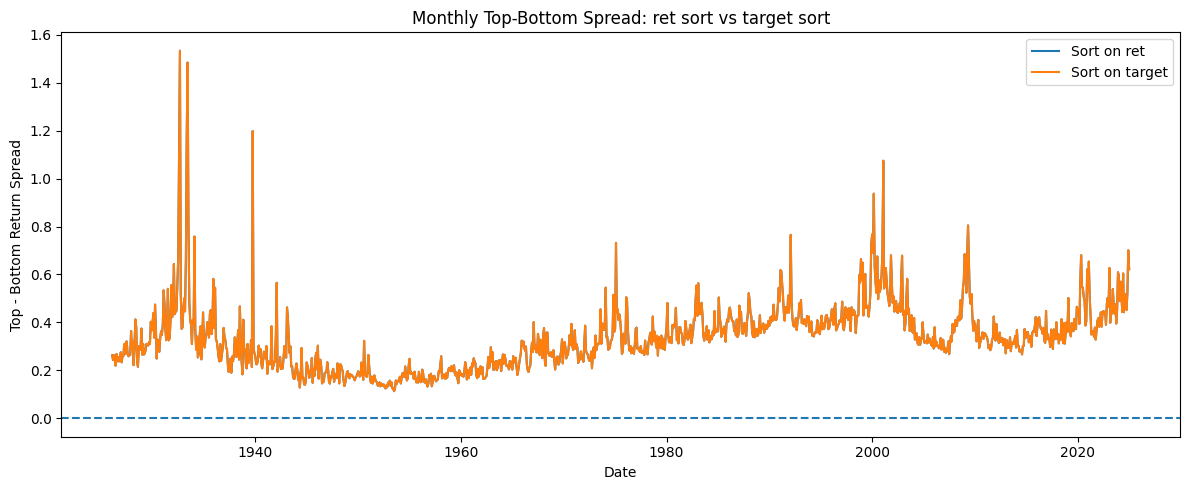

In [17]:
spread_plot = monthly_spread.copy()
spread_plot['date'] = pd.to_datetime(spread_plot['date'])
spread_plot = spread_plot.sort_values('date')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(spread_plot['date'], spread_plot['spread_sort_on_ret'], label='Sort on ret')
ax.plot(spread_plot['date'], spread_plot['spread_sort_on_target'], label='Sort on target')
ax.axhline(0, linestyle='--')
ax.set_title('Monthly Top-Bottom Spread: ret sort vs target sort')
ax.set_xlabel('Date')
ax.set_ylabel('Top - Bottom Return Spread')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
spread_corr_pearson = monthly_spread['spread_sort_on_ret'].corr(
    monthly_spread['spread_sort_on_target'], method='pearson'
)

spread_corr_spearman = monthly_spread['spread_sort_on_ret'].corr(
    monthly_spread['spread_sort_on_target'], method='spearman'
)

print("Pearson correlation between monthly spreads:", spread_corr_pearson)
print("Spearman correlation between monthly spreads:", spread_corr_spearman)

Pearson correlation between monthly spreads: 1.0
Spearman correlation between monthly spreads: 1.0


## Sanity Check: Relationship Between Raw Returns, Normalized Target

In this section we performed a simple sanity check to verify how the normalized target relates to raw returns and how it affects portfolio construction.

### Goal 1: Effect of Cross-Sectional Normalization

We constructed the regression target as a **winsorized cross-sectional z-score** of monthly returns.  
Empirically we observe:

- The **Spearman correlation between `ret` and `target` is essentially 1**.
- This confirms that the **cross-sectional ranking of stocks is preserved** after normalization.

This occurs because z-score normalization (after winsorization) is a **monotonic transformation** of the original returns within each month.

---

### Goal 2: Portfolio Sorting Consistency

Next we compared long–short portfolios formed by sorting on:

- raw returns (`ret`)
- normalized target (`target`)

The results show:

- The **monthly long–short spreads are identical**
- Pearson correlation between the two spread series = **1.0**
- Spearman correlation between the two spread series = **1.0**

This confirms that **sorting on the normalized target produces the same portfolio ordering as sorting on raw returns**.

---

### Implication for the Modeling Framework

These sanity checks justify the modeling design used in the project:

1. **Z-score normalization**  
   - Makes the target comparable across time
   - Reduces the influence of extreme outliers

2. **Rank-based evaluation (Rank IC)**  
   - Because portfolio construction depends on **relative ranking**, not absolute return levels.

3. **Information Coefficient (IC) and ICIR**  
   - The model predicts cross-sectional relative performance.
   - Monthly **Rank IC** measures the correlation between predicted signals and realized rankings.
   - The **IC time series** then leads to the **ICIR (Information Coefficient Information Ratio)**.

---

### Connection to Quantile Portfolio Construction

Finally, this framework naturally connects to **quantile portfolio backtesting**:

1. The model produces a **cross-sectional signal**
2. Stocks are **ranked by the signal**
3. Quantile portfolios (e.g., top vs bottom) are formed
4. Portfolio spreads measure economic performance

Because ranking is preserved under normalization, the **target definition, Rank IC evaluation, ICIR metric, and quantile portfolio construction are all internally consistent** within the modeling pipeline.